# Notebook 4 — Statistical Analysis (bootstrap CIs + McNemar tests)

**CPU-only post-processing** — no GPU, no model. Runs on the per-sample prediction CSVs produced by the evaluation notebooks:

| Input file | Produced by | Required? |
|---|---|---|
| `per_sample_predictions_system.csv` | NB2 (system-level) | yes |
| `per_sample_predictions_baseline.csv` | NB3 (baseline) | yes |
| `per_sample_predictions_merged.csv` | ablation notebook (merged adapter) | optional — enables the ablation significance test |

Outputs:
1. **Bootstrap 95% confidence intervals** for accuracy, precision, recall, F1, FPR, FNR (per adapter on its native subset, system OR-gate, baseline, merged if available) and for AUROC.
2. **McNemar's paired significance tests**: system vs. baseline, and system vs. merged single adapter (the ablation hypothesis test), plus per-adapter vs. baseline on each category subset.

Upload the CSVs next to this notebook (or point `INPUT_DIR` at them) and run all cells.

## 1. Imports and configuration

In [3]:
import os
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

SEED = 42
rng = np.random.default_rng(SEED)

INPUT_DIR = "outputs/new"            # folder containing the per-sample prediction CSVs
OUTPUT_DIR = "outputs/new/result"
os.makedirs(OUTPUT_DIR, exist_ok=True)

N_BOOT = 2000              # bootstrap resamples for threshold metrics
N_BOOT_AUROC = 1000        # AUROC bootstrap (heavier per iteration)
CI = 95

CATEGORIES = [
    "role-and-instruction-violation",
    "privilege-escalation",
    "obfuscation-and-evasion-patterns",
]

SYSTEM_CSV = os.path.join(INPUT_DIR, "per_sample_predictions_system.csv")
BASELINE_CSV = os.path.join(INPUT_DIR, "per_sample_predictions_baseline.csv")
MERGED_CSV = os.path.join(INPUT_DIR, "per_sample_predictions_merged.csv")  # optional

## 2. Load and align the prediction files

In [4]:
sys_df = pd.read_csv(SYSTEM_CSV)
base_df = pd.read_csv(BASELINE_CSV)

print(f"system file:   {len(sys_df):,} rows | cols: {list(sys_df.columns)}")
print(f"baseline file: {len(base_df):,} rows")

# Both notebooks build the combined set identically (same seed, same dedup),
# so rows must align 1:1. Verify before pairing.
assert len(sys_df) == len(base_df), "Row counts differ - were NB2 and NB3 run on the same split/settings?"
assert (sys_df["label"].values == base_df["label"].values).all(), "Labels misaligned between files."
assert (sys_df["category"].values == base_df["category"].values).all(), "Categories misaligned."

y = sys_df["label"].to_numpy()
category = sys_df["category"].to_numpy()
source = sys_df["source"].to_numpy()

preds = {"system_OR": sys_df["pred_system"].to_numpy(),
         "baseline": base_df["pred_baseline"].to_numpy()}
for c in CATEGORIES:
    preds[f"adapter::{c}"] = sys_df[f"pred_{c}"].to_numpy()

scores = {"system_max_score": sys_df["score_system_max"].to_numpy(),
          "baseline": base_df["score_baseline"].to_numpy()}
for c in CATEGORIES:
    scores[f"adapter::{c}"] = sys_df[f"score_{c}"].to_numpy()

HAVE_MERGED = os.path.exists(MERGED_CSV)
if HAVE_MERGED:
    mrg_df = pd.read_csv(MERGED_CSV)
    assert len(mrg_df) == len(sys_df) and (mrg_df["label"].values == y).all(), "Merged file misaligned."
    preds["merged_single_adapter"] = mrg_df["pred_merged"].to_numpy()
    print("Merged-adapter predictions loaded - ablation test enabled.")
else:
    print("No merged-adapter file found - ablation McNemar test will be skipped.")

print(f"\nRows: {len(y):,} | injections: {int(y.sum()):,} | benign: {int((y==0).sum()):,}")

system file:   21,492 rows | cols: ['label', 'source', 'category', 'raw_prompt', 'pred_role-and-instruction-violation', 'score_role-and-instruction-violation', 'pred_privilege-escalation', 'score_privilege-escalation', 'pred_obfuscation-and-evasion-patterns', 'score_obfuscation-and-evasion-patterns', 'pred_system', 'score_system_max']
baseline file: 21,492 rows
No merged-adapter file found - ablation McNemar test will be skipped.

Rows: 21,492 | injections: 5,741 | benign: 15,751


## 3. Bootstrap confidence intervals — threshold metrics

In [5]:
def metric_vector(y_s, p_s):
    """accuracy, precision, recall, f1, fpr, fnr computed from raw counts (fast, no sklearn)."""
    tp = int(((p_s == 1) & (y_s == 1)).sum())
    fp = int(((p_s == 1) & (y_s == 0)).sum())
    fn = int(((p_s == 0) & (y_s == 1)).sum())
    tn = int(((p_s == 0) & (y_s == 0)).sum())
    prec = tp / (tp + fp) if tp + fp else 0.0
    rec = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * prec * rec / (prec + rec) if prec + rec else 0.0
    fpr = fp / (fp + tn) if fp + tn else 0.0
    fnr = fn / (fn + tp) if fn + tp else 0.0
    acc = (tp + tn) / len(y_s)
    return np.array([acc, prec, rec, f1, fpr, fnr])

METRIC_NAMES = ["accuracy", "precision", "recall", "f1", "fpr", "fnr"]

def bootstrap_ci(y_s, p_s, n_boot=N_BOOT):
    n = len(y_s)
    point = metric_vector(y_s, p_s)
    boots = np.empty((n_boot, len(METRIC_NAMES)))
    for b in range(n_boot):
        idx = rng.integers(0, n, n)
        boots[b] = metric_vector(y_s[idx], p_s[idx])
    lo = np.percentile(boots, (100 - CI) / 2, axis=0)
    hi = np.percentile(boots, 100 - (100 - CI) / 2, axis=0)
    return point, lo, hi

rows = []
for name, p in preds.items():
    if name.startswith("adapter::"):
        cat = name.split("::", 1)[1]
        mask = source == cat          # native subset (matches NB1/NB2 per-adapter tables)
        y_s, p_s = y[mask], p[mask]
        scope = "own test subset"
    else:
        y_s, p_s = y, p
        scope = "combined set"
    point, lo, hi = bootstrap_ci(y_s, p_s)
    for m, pt, l, h in zip(METRIC_NAMES, point, lo, hi):
        rows.append({"detector": name, "scope": scope, "metric": m,
                     "value": round(pt, 4), "ci_low": round(l, 4), "ci_high": round(h, 4)})
    print(f"{name} ({scope}): " + " | ".join(
        f"{m}={pt:.4f} [{l:.4f}, {h:.4f}]" for m, pt, l, h in zip(METRIC_NAMES, point, lo, hi)))

ci_df = pd.DataFrame(rows)
ci_df.to_csv(os.path.join(OUTPUT_DIR, "bootstrap_confidence_intervals.csv"), index=False)

system_OR (combined set): accuracy=0.9365 [0.9333, 0.9396] | precision=0.8117 [0.8026, 0.8206] | recall=0.9925 [0.9903, 0.9946] | f1=0.8930 [0.8874, 0.8984] | fpr=0.0839 [0.0799, 0.0882] | fnr=0.0075 [0.0054, 0.0097]
baseline (combined set): accuracy=0.7555 [0.7500, 0.7615] | precision=0.5663 [0.5503, 0.5832] | recall=0.3623 [0.3495, 0.3747] | f1=0.4419 [0.4284, 0.4545] | fpr=0.1011 [0.0962, 0.1057] | fnr=0.6377 [0.6253, 0.6505]
adapter::role-and-instruction-violation (own test subset): accuracy=0.9735 [0.9697, 0.9773] | precision=0.9174 [0.9048, 0.9303] | recall=0.9812 [0.9749, 0.9876] | f1=0.9483 [0.9405, 0.9557] | fpr=0.0290 [0.0244, 0.0338] | fnr=0.0188 [0.0124, 0.0251]
adapter::privilege-escalation (own test subset): accuracy=0.9708 [0.9670, 0.9746] | precision=0.9119 [0.8999, 0.9231] | recall=0.9861 [0.9807, 0.9909] | f1=0.9475 [0.9405, 0.9543] | fpr=0.0349 [0.0301, 0.0397] | fnr=0.0139 [0.0091, 0.0193]
adapter::obfuscation-and-evasion-patterns (own test subset): accuracy=0.9720 

## 4. Bootstrap confidence intervals — AUROC

In [6]:
from sklearn.metrics import roc_auc_score

def bootstrap_auroc(y_s, s_s, n_boot=N_BOOT_AUROC):
    n = len(y_s)
    point = roc_auc_score(y_s, s_s)
    boots = np.empty(n_boot)
    for b in range(n_boot):
        idx = rng.integers(0, n, n)
        yb = y_s[idx]
        if yb.min() == yb.max():      # degenerate resample, redraw is overkill; skip
            boots[b] = np.nan
            continue
        boots[b] = roc_auc_score(yb, s_s[idx])
    boots = boots[~np.isnan(boots)]
    return point, np.percentile(boots, (100 - CI) / 2), np.percentile(boots, 100 - (100 - CI) / 2)

auroc_rows = []
for name, s in scores.items():
    if name.startswith("adapter::"):
        cat = name.split("::", 1)[1]
        mask = source == cat
        y_s, s_s = y[mask], s[mask]
        scope = "own test subset"
    else:
        y_s, s_s = y, s
        scope = "combined set"
    pt, lo, hi = bootstrap_auroc(y_s, s_s)
    auroc_rows.append({"detector": name, "scope": scope,
                       "auroc": round(pt, 4), "ci_low": round(lo, 4), "ci_high": round(hi, 4)})
    print(f"{name} ({scope}): AUROC={pt:.4f} [{lo:.4f}, {hi:.4f}]")

auroc_df = pd.DataFrame(auroc_rows)
auroc_df.to_csv(os.path.join(OUTPUT_DIR, "bootstrap_auroc_cis.csv"), index=False)

system_max_score (combined set): AUROC=0.9962 [0.9955, 0.9967]
baseline (combined set): AUROC=0.7340 [0.7267, 0.7415]
adapter::role-and-instruction-violation (own test subset): AUROC=0.9950 [0.9928, 0.9965]
adapter::privilege-escalation (own test subset): AUROC=0.9980 [0.9974, 0.9985]
adapter::obfuscation-and-evasion-patterns (own test subset): AUROC=0.9985 [0.9981, 0.9989]


## 5. McNemar's paired significance tests

Paired on identical samples: `b` = only the first detector is correct, `c` = only the second is correct. Exact binomial test on (b, c). Reported comparisons:

1. **System OR-gate vs. zero-shot baseline** — is fine-tuning + composition significantly better?
2. **System OR-gate vs. merged single adapter** — the ablation hypothesis test (if merged predictions available).
3. Each adapter vs. baseline on its own category subset.

In [7]:
def mcnemar_exact(y_s, p1, p2):
    c1 = (p1 == y_s)
    c2 = (p2 == y_s)
    b = int((c1 & ~c2).sum())   # detector 1 correct, detector 2 wrong
    c = int((~c1 & c2).sum())   # detector 2 correct, detector 1 wrong
    n = b + c
    if n == 0:
        return b, c, 1.0
    p_val = stats.binomtest(min(b, c), n, 0.5, alternative="two-sided").pvalue
    return b, c, float(p_val)

tests = []

def run_test(name1, p1, name2, p2, y_s, scope):
    b, c, p_val = mcnemar_exact(y_s, p1, p2)
    err1, err2 = float((p1 != y_s).mean()), float((p2 != y_s).mean())
    tests.append({"comparison": f"{name1} vs {name2}", "scope": scope,
                  "error_rate_1": round(err1, 4), "error_rate_2": round(err2, 4),
                  "b_only_1_correct": b, "c_only_2_correct": c,
                  "p_value": p_val,
                  "significant_at_0.05": p_val < 0.05})
    print(f"{name1} vs {name2} ({scope}): err {err1:.4f} vs {err2:.4f} | "
          f"b={b}, c={c} | p={p_val:.2e} {'*SIGNIFICANT*' if p_val < 0.05 else '(n.s.)'}")

run_test("system_OR", preds["system_OR"], "baseline", preds["baseline"], y, "combined set")

if HAVE_MERGED:
    run_test("system_OR", preds["system_OR"],
             "merged_single_adapter", preds["merged_single_adapter"], y, "combined set")
    run_test("merged_single_adapter", preds["merged_single_adapter"],
             "baseline", preds["baseline"], y, "combined set")

for c_ in CATEGORIES:
    mask = source == c_
    run_test(f"adapter::{c_}", preds[f"adapter::{c_}"][mask],
             "baseline", preds["baseline"][mask], y[mask], "own test subset")

tests_df = pd.DataFrame(tests)
tests_df.to_csv(os.path.join(OUTPUT_DIR, "mcnemar_tests.csv"), index=False)
tests_df

system_OR vs baseline (combined set): err 0.0635 vs 0.2445 | b=4873, c=984 | p=0.00e+00 *SIGNIFICANT*
adapter::role-and-instruction-violation vs baseline (own test subset): err 0.0265 vs 0.2217 | b=1395, c=89 | p=2.96e-302 *SIGNIFICANT*
adapter::privilege-escalation vs baseline (own test subset): err 0.0292 vs 0.2447 | b=1806, c=126 | p=0.00e+00 *SIGNIFICANT*
adapter::obfuscation-and-evasion-patterns vs baseline (own test subset): err 0.0280 vs 0.2660 | b=1757, c=90 | p=0.00e+00 *SIGNIFICANT*


,comparison,scope,error_rate_1,error_rate_2,b_only_1_correct,c_only_2_correct,p_value,significant_at_0.05
0,system_OR vs baseline,combined set,0.0635,0.2445,4873,984,0.000000e+00,True
1,adapter::role-and-instruction-violation vs bas...,own test subset,0.0265,0.2217,1395,89,2.961541e-302,True
2,adapter::privilege-escalation vs baseline,own test subset,0.0292,0.2447,1806,126,0.000000e+00,True
3,adapter::obfuscation-and-evasion-patterns vs b...,own test subset,0.0280,0.2660,1757,90,0.000000e+00,True


## 6. Forest plot — F1 with 95% CIs

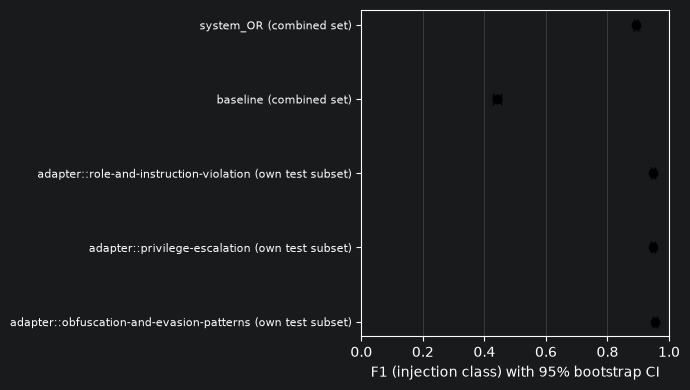

In [8]:
f1 = ci_df[ci_df["metric"] == "f1"].reset_index(drop=True)
fig, ax = plt.subplots(figsize=(7, 0.6 * len(f1) + 1))
ypos = np.arange(len(f1))[::-1]
ax.errorbar(f1["value"], ypos,
            xerr=[f1["value"] - f1["ci_low"], f1["ci_high"] - f1["value"]],
            fmt="o", capsize=4, color="black")
ax.set_yticks(ypos, [f'{r.detector} ({r.scope})' for r in f1.itertuples()], fontsize=8)
ax.set_xlabel("F1 (injection class) with 95% bootstrap CI")
ax.set_xlim(0, 1)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "f1_forest_plot.png"), dpi=200)
plt.show()

## 7. Save summary

In [9]:
summary = {
    "config": {"n_boot": N_BOOT, "n_boot_auroc": N_BOOT_AUROC, "ci": CI, "seed": SEED,
               "rows": int(len(y)), "merged_available": HAVE_MERGED},
    "confidence_intervals": ci_df.to_dict(orient="records"),
    "auroc_cis": auroc_df.to_dict(orient="records"),
    "mcnemar_tests": tests_df.to_dict(orient="records"),
}
with open(os.path.join(OUTPUT_DIR, "statistical_analysis.json"), "w") as f:
    json.dump(summary, f, indent=2)
print("Saved:", sorted(os.listdir(OUTPUT_DIR)))

Saved: ['bootstrap_auroc_cis.csv', 'bootstrap_confidence_intervals.csv', 'f1_forest_plot.png', 'mcnemar_tests.csv', 'statistical_analysis.json']


---
## For the thesis

- **§7.5 / §7.6:** report every headline metric as `value [CI_low, CI_high]` using `bootstrap_confidence_intervals.csv` and `bootstrap_auroc_cis.csv`; include `f1_forest_plot.png`.
- **§7.6 (ablation):** the system-vs-merged McNemar result is the sentence that turns "the ensemble scored higher" into "the difference is statistically significant (p = ...)" — or honestly reports that it is not.
- **§7.9:** if any CI is wide or a McNemar test is non-significant, say so; that is exactly what this notebook exists to reveal.

**Note:** if the merged-adapter predictions file is missing, run the ablation evaluation and save its per-sample predictions as `per_sample_predictions_merged.csv` with columns `label, pred_merged` (aligned to the same combined set).